# NFL Player Contact Detection: EDA and Tracking Context

This notebook establishes the evidence base for player contact detection. It profiles the contact labels, tracking data, helmet boxes, and video metadata; then it builds a first tracking-distance baseline that later modeling notebooks can improve.


## 1. Setup and Configuration

Imports, plotting defaults, path resolution, and fast-run flags live together. The resolver checks Kaggle's `competitions` mount first, then dataset-style fallbacks, and finally scans the visible input directories for the required CSV files.


In [1]:
import gc
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from IPython.display import display
from sklearn.metrics import matthews_corrcoef
from sklearn.model_selection import GroupShuffleSplit

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.frameon": False,
})

RANDOM_STATE = 42
TARGET = "contact"
ID_COL = "contact_id"
RUN_FAST = True
FAST_SAMPLE_PLAYS = 30
FAST_SAMPLE_ROWS = 200_000
DISTANCE_THRESHOLDS = np.round(np.arange(0.2, 3.05, 0.1), 2)
VIDEO_FPS = 59.94
TRACKING_HZ = 10
SNAP_OFFSET_SECONDS = 5
SNAP_FRAME = int(round(VIDEO_FPS * SNAP_OFFSET_SECONDS))

REQUIRED_DATA_FILES = [
    "train_labels.csv",
    "sample_submission.csv",
    "train_player_tracking.csv",
    "test_player_tracking.csv",
    "train_baseline_helmets.csv",
    "test_baseline_helmets.csv",
    "train_video_metadata.csv",
    "test_video_metadata.csv",
]
DATA_DIR_CANDIDATES = [
    Path("/kaggle/input/competitions/nfl-player-contact-detection"),
    Path("/kaggle/input/competitions/1st-and-future-player-contact-detection"),
    Path("/kaggle/input/1st-and-future-player-contact-detection"),
    Path("/kaggle/input/nfl-player-contact-detection"),
    Path("../input/competitions/nfl-player-contact-detection"),
    Path("../input/competitions/1st-and-future-player-contact-detection"),
    Path("../input/1st-and-future-player-contact-detection"),
    Path("../input/nfl-player-contact-detection"),
]


def find_data_dir(
    candidates: list[Path],
    required_files: list[str],
    input_roots: tuple[Path, ...] = (
        Path("/kaggle/input/competitions"),
        Path("/kaggle/input"),
    ),
) -> Path:
    """Find the competition directory that contains the required CSV files."""
    search_paths = list(candidates)
    for input_root in input_roots:
        if input_root.exists():
            search_paths.extend(
                path for path in input_root.iterdir() if path.is_dir()
            )

    seen = set()
    for candidate in search_paths:
        path = candidate.resolve() if candidate.exists() else candidate
        if path in seen:
            continue
        seen.add(path)
        if all((path / filename).exists() for filename in required_files):
            return path

    available = {}
    for input_root in input_roots:
        if input_root.exists():
            available[str(input_root)] = sorted(
                path.name for path in input_root.iterdir()
            )
    raise FileNotFoundError(
        "Could not find the NFL contact detection data directory. "
        f"Checked: {[str(path) for path in search_paths]}. "
        f"Available input directories: {available}"
    )


DATA_DIR = find_data_dir(DATA_DIR_CANDIDATES, REQUIRED_DATA_FILES)
OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path(".")

print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR.resolve()}")


DATA_DIR: /kaggle/input/competitions/nfl-player-contact-detection
OUTPUT_DIR: /kaggle/working


## 2. Helper Functions

The helpers keep contact ID parsing, memory reduction, plotting, distance scoring, and contact-run summaries consistent across the EDA and baseline notebooks.


In [2]:
def reduce_memory_usage(df: pd.DataFrame) -> pd.DataFrame:
    """Downcast dataframe columns to reduce notebook memory usage."""
    out = df.copy()
    for col in out.columns:
        dtype = out[col].dtype
        if pd.api.types.is_integer_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="integer")
        elif pd.api.types.is_float_dtype(dtype):
            out[col] = pd.to_numeric(out[col], downcast="float")
        elif pd.api.types.is_object_dtype(dtype):
            nunique = out[col].nunique(dropna=False)
            if nunique / max(len(out), 1) < 0.5 and col != ID_COL:
                out[col] = out[col].astype("category")
    return out


def parse_contact_id(df: pd.DataFrame) -> pd.DataFrame:
    """Split Kaggle contact_id into play, step, player1, and player2 fields."""
    out = df.copy()
    parts = out[ID_COL].astype(str).str.split("_", expand=True)
    if parts.shape[1] != 5:
        raise ValueError(f"Expected 5 contact_id parts, found {parts.shape[1]}")
    out["game_play"] = parts[0] + "_" + parts[1]
    out["step"] = parts[2].astype("int16")
    out["nfl_player_id_1"] = parts[3].astype(str)
    out["nfl_player_id_2"] = parts[4].astype(str)
    out["contact_type"] = np.where(
        out["nfl_player_id_2"].eq("G"), "ground", "player_player"
    )
    out["pair_key"] = (
        out["game_play"].astype(str) + "_"
        + out["nfl_player_id_1"].astype(str) + "_"
        + out["nfl_player_id_2"].astype(str)
    )
    return out


def dataframe_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    """Summarize column types, missingness, unique values, and memory."""
    return pd.DataFrame({
        "dataset": name,
        "dtype": df.dtypes.astype(str),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean().mul(100),
        "unique": df.nunique(dropna=False),
        "memory_mb": df.memory_usage(deep=True).div(1024 ** 2),
    }).sort_values(["missing_pct", "unique"], ascending=[False, False])


def maybe_sample_plays(df: pd.DataFrame, n_plays: int) -> pd.DataFrame:
    """Return all rows for a reproducible sample of game_play values."""
    plays = pd.Series(df["game_play"].unique()).sample(
        min(n_plays, df["game_play"].nunique()),
        random_state=RANDOM_STATE,
    )
    return df[df["game_play"].isin(plays)].copy()


def maybe_sample_rows(df: pd.DataFrame, n_rows: int) -> pd.DataFrame:
    """Sample rows reproducibly when plotting very large tables."""
    if len(df) <= n_rows:
        return df.copy()
    return df.sample(n_rows, random_state=RANDOM_STATE).copy()


def create_football_field(
    linenumbers: bool = True,
    endzones: bool = True,
    figsize: tuple[int, int] = (12, 6),
    line_color: str = "black",
    field_color: str = "white",
    endzone_color=None,
    ax=None,
):
    """Draw a football field for tracking-data visualization."""
    if endzone_color is None:
        endzone_color = field_color
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    rect = patches.Rectangle(
        (0, 0), 120, 53.3, linewidth=0.1, edgecolor=line_color,
        facecolor=field_color, zorder=0,
    )
    ax.add_patch(rect)
    for x in range(10, 120, 10):
        ax.plot([x, x], [0, 53.3], color=line_color, linewidth=0.8)
    if endzones:
        ax.add_patch(patches.Rectangle(
            (0, 0), 10, 53.3, linewidth=0.1, edgecolor=line_color,
            facecolor=endzone_color, alpha=0.5, zorder=0,
        ))
        ax.add_patch(patches.Rectangle(
            (110, 0), 10, 53.3, linewidth=0.1, edgecolor=line_color,
            facecolor=endzone_color, alpha=0.5, zorder=0,
        ))

    if linenumbers:
        for x in range(20, 110, 10):
            number = x if x <= 50 else 120 - x
            label = str(number - 10)
            ax.text(x, 5, label, ha="center", fontsize=16, color=line_color)
            ax.text(
                x, 48.3, label, ha="center", fontsize=16,
                color=line_color, rotation=180,
            )

    hash_range = range(11, 110) if endzones else range(1, 120)
    for x in hash_range:
        ax.plot([x, x], [0.4, 0.7], color=line_color, linewidth=0.6)
        ax.plot([x, x], [52.6, 52.9], color=line_color, linewidth=0.6)
        ax.plot([x, x], [22.91, 23.57], color=line_color, linewidth=0.6)
        ax.plot([x, x], [29.73, 30.39], color=line_color, linewidth=0.6)

    ax.set_xlim(-5, 125)
    ax.set_ylim(-5, 58.3)
    ax.axis("off")
    return ax


def compute_pair_distances(
    contacts: pd.DataFrame,
    tracking: pd.DataFrame,
) -> pd.DataFrame:
    """Attach player coordinates and compute player-player distance in yards."""
    pairs = contacts[contacts["nfl_player_id_2"].ne("G")].copy()
    track_cols = [
        "game_play", "step", "nfl_player_id", "x_position", "y_position"
    ]
    track = tracking[track_cols].copy()
    for col in ["nfl_player_id", "nfl_player_id_1", "nfl_player_id_2"]:
        if col in track.columns:
            track[col] = track[col].astype(str)
        if col in pairs.columns:
            pairs[col] = pairs[col].astype(str)

    out = pairs.merge(
        track,
        left_on=["game_play", "step", "nfl_player_id_1"],
        right_on=["game_play", "step", "nfl_player_id"],
        how="left",
    ).rename(columns={
        "x_position": "x_position_1",
        "y_position": "y_position_1",
    }).drop(columns=["nfl_player_id"])

    out = out.merge(
        track,
        left_on=["game_play", "step", "nfl_player_id_2"],
        right_on=["game_play", "step", "nfl_player_id"],
        how="left",
    ).rename(columns={
        "x_position": "x_position_2",
        "y_position": "y_position_2",
    }).drop(columns=["nfl_player_id"])

    out["distance"] = np.sqrt(
        np.square(out["x_position_1"] - out["x_position_2"])
        + np.square(out["y_position_1"] - out["y_position_2"])
    )
    return out


def score_distance_thresholds(
    df: pd.DataFrame,
    thresholds: np.ndarray,
) -> pd.DataFrame:
    """Score distance thresholds while predicting ground rows as no-contact."""
    rows = []
    y_true = df[TARGET].astype(int).to_numpy()
    contact_type = df["contact_type"].to_numpy()
    distances = df["distance"].to_numpy()
    is_pair = contact_type == "player_player"

    for threshold in thresholds:
        pred = np.zeros(len(df), dtype=np.int8)
        pred[is_pair] = np.nan_to_num(distances[is_pair], nan=np.inf) <= threshold
        rows.append({
            "threshold": threshold,
            "mcc": matthews_corrcoef(y_true, pred),
            "positive_rate": pred.mean(),
        })
    return pd.DataFrame(rows).sort_values("mcc", ascending=False)


def summarize_contact_runs(labels_df: pd.DataFrame) -> pd.DataFrame:
    """Summarize contiguous positive contact runs by play/pair/type."""
    positives = labels_df.loc[
        labels_df[TARGET].eq(1),
        ["game_play", "pair_key", "contact_type", "step"],
    ].sort_values(["pair_key", "step"])
    if positives.empty:
        return positives.assign(run_length_steps=[])

    new_run = (
        positives["pair_key"].ne(positives["pair_key"].shift())
        | positives["step"].sub(positives["step"].shift()).ne(1)
    )
    positives = positives.assign(run_id=new_run.cumsum())
    return (
        positives.groupby(["game_play", "pair_key", "contact_type", "run_id"], observed=True)
        .agg(
            start_step=("step", "min"),
            end_step=("step", "max"),
            run_length_steps=("step", "size"),
        )
        .reset_index()
        .assign(duration_seconds=lambda df: df["run_length_steps"] / TRACKING_HZ)
    )


## 3. Load Data

Read the core competition tables. Both train and test metadata are loaded because the scoring notebook will receive test tracking, helmet, metadata, and submission rows at inference time.


In [3]:
labels = reduce_memory_usage(pd.read_csv(
    DATA_DIR / "train_labels.csv",
    parse_dates=["datetime"],
))
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
train_tracking = reduce_memory_usage(pd.read_csv(
    DATA_DIR / "train_player_tracking.csv",
    parse_dates=["datetime"],
))
test_tracking = reduce_memory_usage(pd.read_csv(
    DATA_DIR / "test_player_tracking.csv",
    parse_dates=["datetime"],
))
train_helmets = reduce_memory_usage(pd.read_csv(
    DATA_DIR / "train_baseline_helmets.csv",
))
test_helmets = reduce_memory_usage(pd.read_csv(
    DATA_DIR / "test_baseline_helmets.csv",
))
train_video_metadata = pd.read_csv(
    DATA_DIR / "train_video_metadata.csv",
    parse_dates=["start_time", "end_time", "snap_time"],
)
test_video_metadata = pd.read_csv(
    DATA_DIR / "test_video_metadata.csv",
    parse_dates=["start_time", "end_time", "snap_time"],
)

labels = parse_contact_id(labels)
sample_submission = parse_contact_id(sample_submission)

shape_summary = pd.DataFrame({
    "dataset": [
        "labels", "sample_submission", "train_tracking", "test_tracking",
        "train_helmets", "test_helmets", "train_video_metadata",
        "test_video_metadata",
    ],
    "rows": [
        len(labels), len(sample_submission), len(train_tracking), len(test_tracking),
        len(train_helmets), len(test_helmets), len(train_video_metadata),
        len(test_video_metadata),
    ],
    "columns": [
        labels.shape[1], sample_submission.shape[1], train_tracking.shape[1],
        test_tracking.shape[1], train_helmets.shape[1], test_helmets.shape[1],
        train_video_metadata.shape[1], test_video_metadata.shape[1],
    ],
})
display(shape_summary)
labels.head()


,dataset,rows,columns
0,labels,4721618,9
1,sample_submission,49588,8
2,train_tracking,1353053,17
3,test_tracking,14872,17
4,train_helmets,3783616,12
5,test_helmets,47330,12
6,train_video_metadata,480,7
7,test_video_metadata,4,7


,contact_id,game_play,datetime,step,nfl_player_id_1,nfl_player_id_2,contact,contact_type,pair_key
0,58168_003392_0_38590_43854,58168_003392,2020-09-11 03:01:48.100000+00:00,0,38590,43854,0,player_player,58168_003392_38590_43854
1,58168_003392_0_38590_41257,58168_003392,2020-09-11 03:01:48.100000+00:00,0,38590,41257,0,player_player,58168_003392_38590_41257
2,58168_003392_0_38590_41944,58168_003392,2020-09-11 03:01:48.100000+00:00,0,38590,41944,0,player_player,58168_003392_38590_41944
3,58168_003392_0_38590_42386,58168_003392,2020-09-11 03:01:48.100000+00:00,0,38590,42386,0,player_player,58168_003392_38590_42386
4,58168_003392_0_38590_47944,58168_003392,2020-09-11 03:01:48.100000+00:00,0,38590,47944,0,player_player,58168_003392_38590_47944


### Current Run Takeaway

The latest Kaggle run loaded `4,721,618` label rows, `1,353,053` train tracking rows, `3,783,616` train helmet rows, and `480` train video metadata rows. The overall contact rate was about `1.37%`, so MCC and recall-oriented diagnostics matter much more than accuracy.


## 4. Data Quality and Schema Checks

Before interpreting signals, check missingness, duplicates, ID parsing, file coverage, and train/test schema alignment.


In [4]:
quality_checks = pd.DataFrame({
    "check": [
        "duplicated label rows",
        "duplicated contact_id",
        "label game_play count",
        "train tracking game_play count",
        "test sample game_play count",
        "sample duplicated contact_id",
        "train/test tracking shared columns",
        "train/test helmet shared columns",
    ],
    "value": [
        int(labels.duplicated().sum()),
        int(labels[ID_COL].duplicated().sum()),
        int(labels["game_play"].nunique()),
        int(train_tracking["game_play"].nunique()),
        int(sample_submission["game_play"].nunique()),
        int(sample_submission[ID_COL].duplicated().sum()),
        len(set(train_tracking.columns).intersection(test_tracking.columns)),
        len(set(train_helmets.columns).intersection(test_helmets.columns)),
    ],
})

display(pd.concat([
    dataframe_overview(labels, "labels"),
    dataframe_overview(train_tracking, "train_tracking"),
    dataframe_overview(train_helmets, "train_helmets"),
]))
display(quality_checks)

schema_checks = {
    "tracking_train_only": sorted(set(train_tracking.columns) - set(test_tracking.columns)),
    "tracking_test_only": sorted(set(test_tracking.columns) - set(train_tracking.columns)),
    "helmet_train_only": sorted(set(train_helmets.columns) - set(test_helmets.columns)),
    "helmet_test_only": sorted(set(test_helmets.columns) - set(train_helmets.columns)),
    "metadata_train_only": sorted(set(train_video_metadata.columns) - set(test_video_metadata.columns)),
    "metadata_test_only": sorted(set(test_video_metadata.columns) - set(train_video_metadata.columns)),
}
display(pd.Series(schema_checks, name="column_differences"))


,dataset,dtype,missing,missing_pct,unique,memory_mb
contact_id,labels,object,0.0,0.0,4721618.0,340.181390
pair_key,labels,object,0.0,0.0,60698.0,327.144224
datetime,labels,"datetime64[ns, UTC]",0.0,0.0,18666.0,36.023087
nfl_player_id_1,labels,object,0.0,0.0,1687.0,243.155834
nfl_player_id_2,labels,object,0.0,0.0,1646.0,241.589394
game_play,labels,object,0.0,0.0,240.0,274.676035
step,labels,int16,0.0,0.0,173.0,9.005772
contact,labels,int8,0.0,0.0,2.0,4.502886
contact_type,labels,object,0.0,0.0,2.0,276.437650
Index,labels,NaN,NaN,NaN,NaN,0.000126


,check,value
0,duplicated label rows,0
1,duplicated contact_id,0
2,label game_play count,240
3,train tracking game_play count,240
4,test sample game_play count,2
5,sample duplicated contact_id,0
6,train/test tracking shared columns,17
7,train/test helmet shared columns,12


tracking_train_only    []
tracking_test_only     []
helmet_train_only      []
helmet_test_only       []
metadata_train_only    []
metadata_test_only     []
Name: column_differences, dtype: object

## 5. Contact Label Balance

The task combines two related but distinct problems: player-player contact and player-ground contact. This section measures the imbalance and play-level variation that validation needs to preserve.


,count,contact_rate,positive_count
contact_type,,,
ground,410633,0.040947,16814
player_player,4310985,0.011067,47708


Overall contact rate: 0.01367


,rows,positive_contacts,contact_rate,max_step,players,pairs,play_seconds
game_play,,,,,,,
58204_002864,15180,709,0.046706,59,22,253,6.0
58216_001939,16445,688,0.041836,64,22,253,6.5
58552_000100,11638,481,0.041330,45,22,253,4.6
58176_002844,14927,596,0.039928,58,22,253,5.9
58403_001076,14927,566,0.037918,58,22,253,5.9
58308_004092,19481,733,0.037626,76,22,253,7.7
58551_003569,20240,750,0.037055,79,22,253,8.0
58224_002486,16951,587,0.034629,66,22,253,6.7
58362_003882,14421,498,0.034533,56,22,253,5.7


,count,mean,std,min,25%,50%,75%,max
rows,240.0,19673.408333,4853.011589,9361.0,16698.000000,18975.000000,21758.000000,43769.000000
positive_contacts,240.0,268.841667,159.543753,0.0,148.500000,235.500000,363.000000,750.000000
contact_rate,240.0,0.014158,0.009181,0.0,0.007444,0.011334,0.019105,0.046706
max_step,240.0,76.783333,19.160928,36.0,65.000000,74.000000,85.000000,172.000000
players,240.0,21.995833,0.064550,21.0,22.000000,22.000000,22.000000,22.000000
pairs,240.0,252.908333,1.420094,231.0,253.000000,253.000000,253.000000,253.000000
play_seconds,240.0,7.778333,1.916093,3.7,6.600000,7.500000,8.600000,17.300000


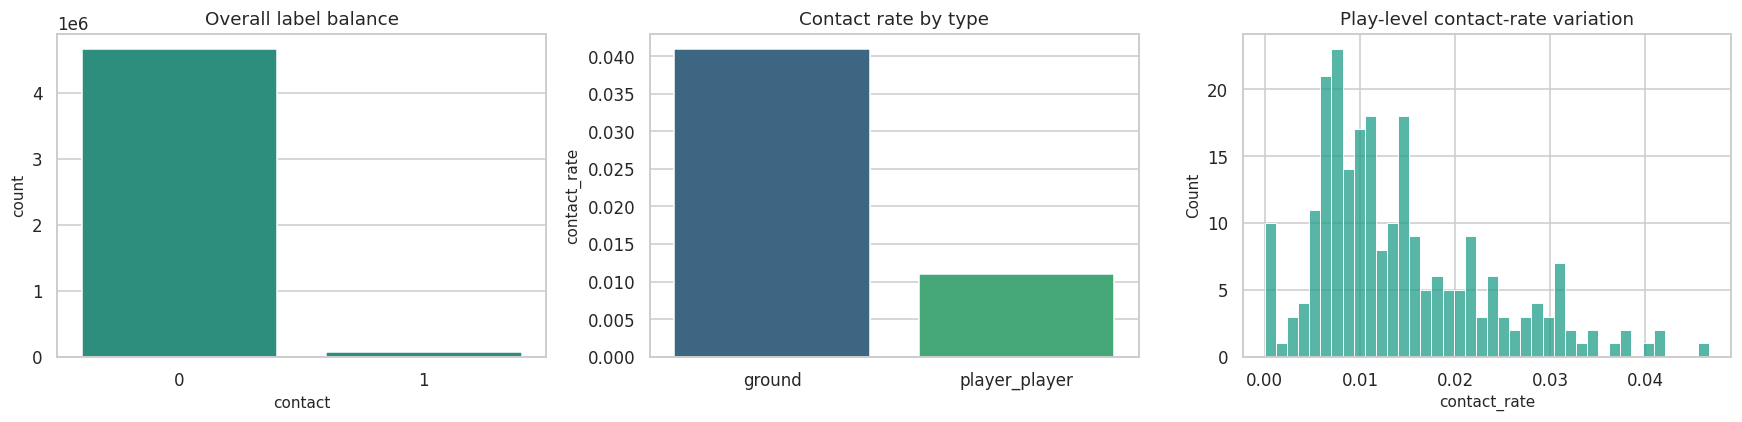

In [5]:
label_summary = (
    labels.groupby("contact_type", observed=True)[TARGET]
    .agg(["count", "mean", "sum"])
    .rename(columns={"mean": "contact_rate", "sum": "positive_count"})
)
display(label_summary)
print(f"Overall contact rate: {labels[TARGET].mean():.5f}")

play_summary = (
    labels.groupby("game_play", observed=True)
    .agg(
        rows=(TARGET, "size"),
        positive_contacts=(TARGET, "sum"),
        contact_rate=(TARGET, "mean"),
        max_step=("step", "max"),
        players=("nfl_player_id_1", "nunique"),
        pairs=("pair_key", "nunique"),
    )
    .assign(play_seconds=lambda df: (df["max_step"] + 1) / TRACKING_HZ)
    .sort_values("contact_rate", ascending=False)
)
display(play_summary.head(12))
display(play_summary.describe().T)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=labels, x=TARGET, color=sns.color_palette("viridis", 8)[4], ax=axes[0])
axes[0].set_title("Overall label balance")
sns.barplot(
    data=label_summary.reset_index(),
    x="contact_type",
    y="contact_rate",
    palette="viridis",
    ax=axes[1],
)
axes[1].set_title("Contact rate by type")
axes[1].set_xlabel("")
sns.histplot(play_summary["contact_rate"], bins=40, color=sns.color_palette("viridis", 8)[4], ax=axes[2])
axes[2].set_title("Play-level contact-rate variation")
plt.tight_layout()
plt.show()


### Label Takeaway

The positive class is very rare overall, but contact is clustered by play, pair, and time. Validation should therefore remain grouped by `game_play`; random row splits would overstate performance by sharing nearly identical moments across train and validation.


## 6. Temporal Contact Dynamics

Labels are provided at 10 Hz and may be noisy within roughly one timestep. Run-length and step-level views reveal how long contacts persist and where in plays contacts concentrate.


,positive_runs,mean,median,max
contact_type,,,,
ground,676,2.487278,2.4,10.6
player_player,3505,1.361141,1.0,7.2


,game_play,pair_key,contact_type,run_id,start_step,end_step,run_length_steps,duration_seconds
1062,58224_003139,58224_003139_47788_G,ground,1063,29,134,106,10.6
1065,58224_003139,58224_003139_47822_G,ground,1066,60,134,75,7.5
3095,58516_003538,58516_003538_44832_47878,player_player,3096,6,77,72,7.2
798,58213_004027,58213_004027_46215_G,ground,799,46,115,70,7.0
3525,58541_000795,58541_000795_42356_44944,player_player,3526,4,71,68,6.8
948,58219_002964,58219_002964_52441_52631,player_player,949,45,110,66,6.6
2086,58326_002516,58326_002516_46277_46825,player_player,2087,10,73,64,6.4
1183,58240_000086,58240_000086_41341_42392,player_player,1184,7,70,64,6.4
2527,58406_000188,58406_000188_41296_47802,player_player,2528,4,64,61,6.1
2906,58507_003903,58507_003903_38559_G,ground,2907,23,83,61,6.1


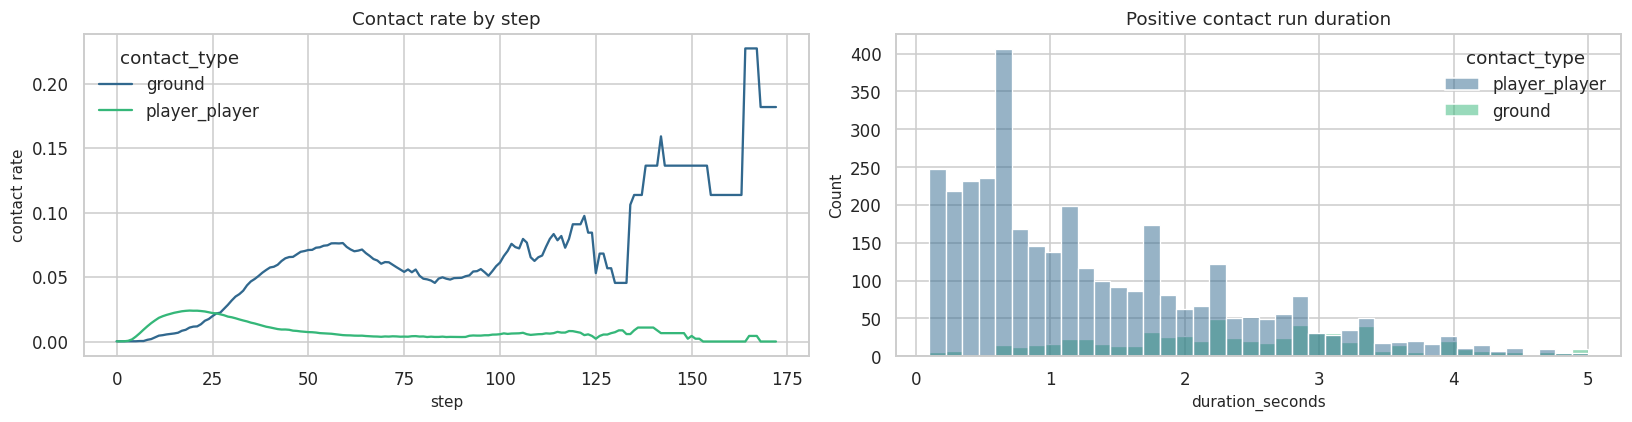

In [6]:
step_summary = (
    labels.groupby(["contact_type", "step"], observed=True)[TARGET]
    .agg(["count", "sum", "mean"])
    .rename(columns={"sum": "positive_count", "mean": "contact_rate"})
    .reset_index()
)
contact_runs = summarize_contact_runs(labels)
run_summary = (
    contact_runs.groupby("contact_type", observed=True)["duration_seconds"]
    .agg(["count", "mean", "median", "max"])
    .rename(columns={"count": "positive_runs"})
)

display(run_summary)
display(contact_runs.sort_values("duration_seconds", ascending=False).head(12))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.lineplot(
    data=step_summary,
    x="step",
    y="contact_rate",
    hue="contact_type",
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Contact rate by step")
axes[0].set_ylabel("contact rate")
plot_runs = contact_runs.query("duration_seconds <= 5")
sns.histplot(
    data=plot_runs,
    x="duration_seconds",
    hue="contact_type",
    bins=40,
    palette="viridis",
    multiple="layer",
    ax=axes[1],
)
axes[1].set_title("Positive contact run duration")
plt.tight_layout()
plt.show()


## 7. Tracking Context and Motion Slices

Tracking features explain body location and movement at 10 Hz. Ground contact likely needs motion and posture proxies, while player-player contact starts with pair distance and relative movement.


,count,mean,std,min,25%,50%,75%,max
game_key,1353053.0,58365.798892,137.696060,58168.00,58225.000000,58330.000000,58516.000000,58582.000000
play_id,1353053.0,2156.408095,1211.457383,40.00,1016.000000,2369.000000,3139.000000,4644.000000
nfl_player_id,1353053.0,44747.017081,4831.883106,25511.00,42352.000000,44893.000000,47814.000000,53985.000000
step,1353053.0,-11.900465,112.549475,-339.00,-86.000000,-15.000000,49.000000,692.000000
jersey_number,1353053.0,51.282450,28.636098,1.00,25.000000,52.000000,76.000000,99.000000
x_position,1353053.0,60.308060,26.804514,-7.47,38.480000,59.689999,81.709999,125.650002
y_position,1353053.0,26.758907,8.502809,-12.87,22.490000,26.740000,31.040001,63.720001
speed,1353053.0,1.259892,1.656287,0.00,0.120000,0.650000,1.620000,14.890000
distance,1353053.0,0.128708,0.166279,0.00,0.020000,0.070000,0.160000,2.220000
direction,1353053.0,179.698868,103.967316,0.00,90.029999,179.240005,269.329987,360.000000


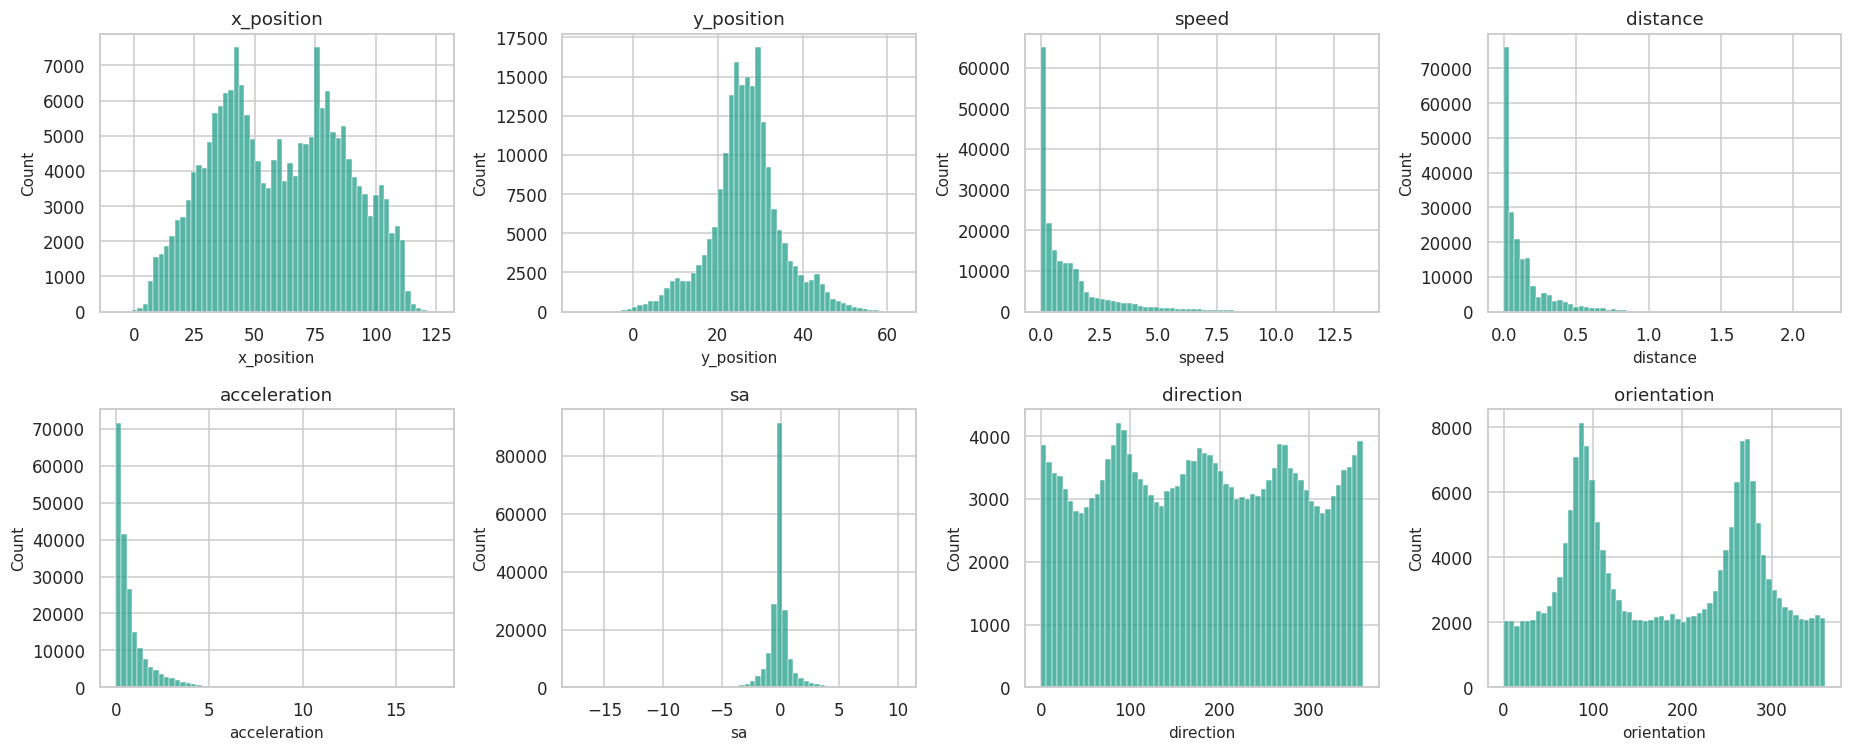

speed                   distance                  acceleration  \
             mean median       std      mean median       std         mean   
contact                                                                      
0        2.727940   2.08  2.145260  0.275702   0.21  0.215587     1.624222   
1        0.916506   0.58  1.005896  0.096332   0.06  0.103463     1.444442   

                                sa                   
        median       std      mean median       std  
contact                                              
0         1.36  1.187112 -0.113633  -0.20  1.561975  
1         0.95  1.318765 -0.653108  -0.22  1.564027

In [7]:
tracking_numeric = train_tracking.select_dtypes(include=[np.number]).columns.tolist()
display(train_tracking[tracking_numeric].describe().T)

plot_cols = [
    col for col in [
        "x_position", "y_position", "speed", "distance",
        "acceleration", "sa", "direction", "orientation",
    ]
    if col in train_tracking.columns
]
tracking_plot = maybe_sample_rows(train_tracking, FAST_SAMPLE_ROWS)
fig, axes = plt.subplots(2, 4, figsize=(17, 7))
axes = np.ravel(axes)
for ax, col in zip(axes, plot_cols):
    sns.histplot(
        tracking_plot[col].dropna(),
        bins=60,
        color=sns.color_palette("viridis", 8)[4],
        ax=ax,
    )
    ax.set_title(col)
for ax in axes[len(plot_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

motion_cols = [
    col for col in ["speed", "distance", "acceleration", "sa"]
    if col in train_tracking.columns
]
ground_labels = labels.loc[
    labels["contact_type"].eq("ground"),
    [ID_COL, "game_play", "step", "nfl_player_id_1", TARGET],
].copy()
ground_sample = maybe_sample_rows(ground_labels, FAST_SAMPLE_ROWS)
ground_motion = ground_sample.merge(
    train_tracking[["game_play", "step", "nfl_player_id"] + motion_cols].assign(
        nfl_player_id=lambda df: df["nfl_player_id"].astype(str)
    ),
    left_on=["game_play", "step", "nfl_player_id_1"],
    right_on=["game_play", "step", "nfl_player_id"],
    how="left",
)
if motion_cols:
    display(ground_motion.groupby(TARGET)[motion_cols].agg(["mean", "median", "std"]))


## 8. Player-Player Distance Deep Dive

The starter baseline uses tracking distance. Here we inspect the distance distribution and contact rate by distance bin before converting it into a hard-threshold MCC baseline.


,count,positive_count,contact_rate
distance_bin,,,
"(-0.001, 0.5]",547,416,0.760512
"(0.5, 1.0]",6381,3316,0.519668
"(1.0, 1.5]",9659,1357,0.140491
"(1.5, 2.0]",11464,104,0.009072
"(2.0, 3.0]",26052,22,0.000844
"(3.0, 5.0]",58756,2,0.000034
"(5.0, 10.0]",122505,0,0.000000
"(10.0, 120.0]",312568,0,0.000000


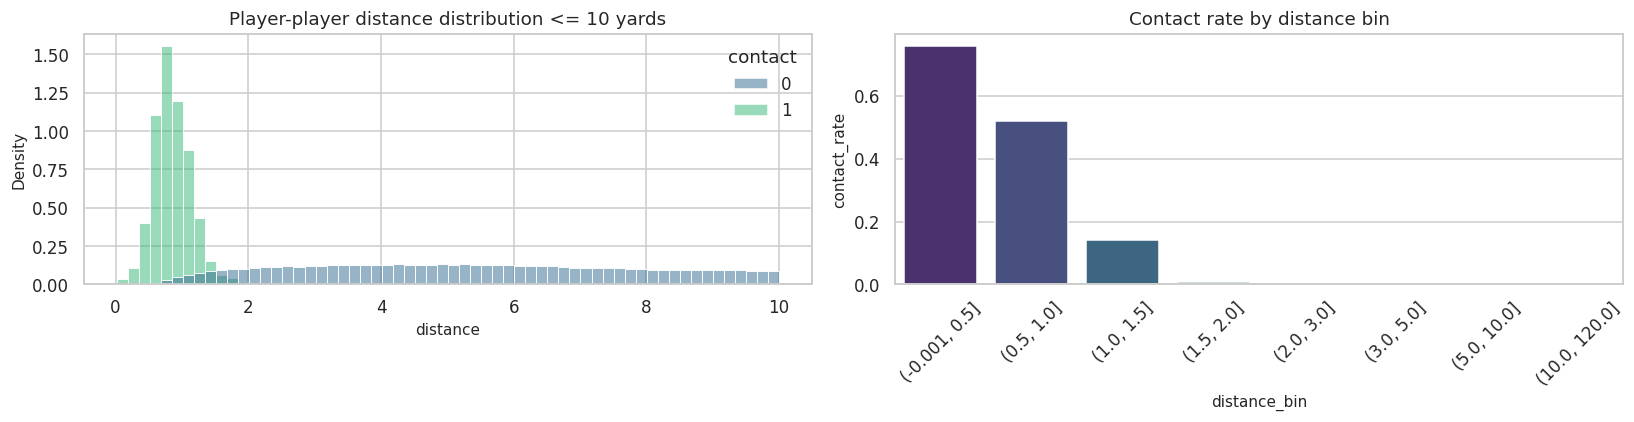

In [8]:
distance_labels = labels[[
    ID_COL, TARGET, "game_play", "step", "nfl_player_id_1",
    "nfl_player_id_2", "contact_type", "pair_key",
]].copy()
if RUN_FAST:
    distance_labels = maybe_sample_plays(distance_labels, FAST_SAMPLE_PLAYS)

distance_pairs = compute_pair_distances(distance_labels, train_tracking)
distance_scoring = distance_labels.merge(
    distance_pairs[[ID_COL, "distance"]],
    on=ID_COL,
    how="left",
)

pair_distance = distance_scoring.query("contact_type == 'player_player'").copy()
pair_distance["distance_bin"] = pd.cut(
    pair_distance["distance"],
    bins=[0, 0.5, 1, 1.5, 2, 3, 5, 10, 120],
    include_lowest=True,
)
distance_bin_summary = (
    pair_distance.groupby("distance_bin", observed=True)[TARGET]
    .agg(["count", "sum", "mean"])
    .rename(columns={"sum": "positive_count", "mean": "contact_rate"})
)
display(distance_bin_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(
    data=pair_distance.query("distance <= 10"),
    x="distance",
    hue=TARGET,
    bins=60,
    palette="viridis",
    stat="density",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("Player-player distance distribution <= 10 yards")
sns.barplot(
    data=distance_bin_summary.reset_index(),
    x="distance_bin",
    y="contact_rate",
    palette="viridis",
    ax=axes[1],
)
axes[1].set_title("Contact rate by distance bin")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 9. Helmet and Video Metadata Context

Baseline helmet boxes are imperfect but valuable for connecting video evidence to tracked players. Video metadata has timing fields, while the helmet files carry the actual video filenames.


In [9]:
helmet_summary = pd.DataFrame({
    "dataset": ["train_helmets", "test_helmets"],
    "rows": [len(train_helmets), len(test_helmets)],
    "videos": [train_helmets["video"].nunique(), test_helmets["video"].nunique()],
    "game_plays": [train_helmets["game_play"].nunique(), test_helmets["game_play"].nunique()],
    "players": [train_helmets["nfl_player_id"].nunique(), test_helmets["nfl_player_id"].nunique()],
})
display(helmet_summary)

video_summary = pd.concat([
    train_video_metadata.assign(dataset="train"),
    test_video_metadata.assign(dataset="test"),
], ignore_index=True)
video_summary["duration_seconds"] = (
    video_summary["end_time"] - video_summary["start_time"]
).dt.total_seconds()
video_summary["snap_offset_seconds"] = (
    video_summary["snap_time"] - video_summary["start_time"]
).dt.total_seconds()
video_summary["estimated_frames"] = (
    video_summary["duration_seconds"] * VIDEO_FPS
).round().astype("int")
display(video_summary.head())
display(video_summary.groupby(["dataset", "view"], observed=True).agg(
    rows=("game_play", "size"),
    game_plays=("game_play", "nunique"),
    median_duration_seconds=("duration_seconds", "median"),
    median_snap_offset_seconds=("snap_offset_seconds", "median"),
    median_estimated_frames=("estimated_frames", "median"),
))

helmet_frame_summary = (
    train_helmets.groupby(["view", "video"], observed=True)
    .agg(
        frames=("frame", "nunique"),
        boxes=("frame", "size"),
        players=("nfl_player_id", "nunique"),
    )
    .assign(boxes_per_frame=lambda df: df["boxes"] / df["frames"])
    .reset_index()
)
display(helmet_frame_summary.groupby("view", observed=True).agg(
    videos=("video", "nunique"),
    median_frames=("frames", "median"),
    median_players=("players", "median"),
    median_boxes_per_frame=("boxes_per_frame", "median"),
))

box_cols = [c for c in ["left", "width", "top", "height"] if c in train_helmets]
if box_cols:
    display(train_helmets[box_cols].describe().T)


,dataset,rows,videos,game_plays,players
0,train_helmets,3783616,481,240,1687
1,test_helmets,47330,4,2,44


,game_play,game_key,play_id,view,start_time,end_time,snap_time,dataset,duration_seconds,snap_offset_seconds,estimated_frames
0,58168_003392,58168,3392,Endzone,2020-09-11 03:01:43.134000+00:00,2020-09-11 03:01:54.971000+00:00,2020-09-11 03:01:48.134000+00:00,train,11.837,5.0,710
1,58168_003392,58168,3392,Sideline,2020-09-11 03:01:43.134000+00:00,2020-09-11 03:01:54.971000+00:00,2020-09-11 03:01:48.134000+00:00,train,11.837,5.0,710
2,58172_003247,58172,3247,Endzone,2020-09-13 19:30:42.414000+00:00,2020-09-13 19:31:00.524000+00:00,2020-09-13 19:30:47.414000+00:00,train,18.110,5.0,1086
3,58172_003247,58172,3247,Sideline,2020-09-13 19:30:42.414000+00:00,2020-09-13 19:31:00.524000+00:00,2020-09-13 19:30:47.414000+00:00,train,18.110,5.0,1086
4,58173_003606,58173,3606,Endzone,2020-09-13 19:45:07.527000+00:00,2020-09-13 19:45:26.438000+00:00,2020-09-13 19:45:12.527000+00:00,train,18.911,5.0,1134


rows  game_plays  median_duration_seconds  \
dataset view                                                  
test    Endzone      2           2                  14.9735   
        Sideline     2           2                  14.9735   
train   Endzone    240         240                  12.5960   
        Sideline   240         240                  12.5960   

                  median_snap_offset_seconds  median_estimated_frames  
dataset view                                                           
test    Endzone                          5.0                    898.0  
        Sideline                         5.0                    898.0  
train   Endzone                          5.0                    755.0  
        Sideline                         5.0                    755.0

,videos,median_frames,median_players,median_boxes_per_frame
view,,,,
Endzone,240,465.0,22.0,14.751538
Endzone2,1,449.0,20.0,14.512249
Sideline,240,465.0,22.0,18.873170


,count,mean,std,min,25%,50%,75%,max
left,3783616.0,629.549037,266.543113,0.0,444.0,632.0,815.0,1278.0
width,3783616.0,17.945528,8.656632,2.0,11.0,16.0,24.0,82.0
top,3783616.0,305.039248,119.258336,0.0,235.0,301.0,372.0,718.0
height,3783616.0,19.026638,9.384617,2.0,12.0,17.0,25.0,89.0


## 10. Example Field View

Plot one play and step on a football field to verify coordinate orientation and team separation.


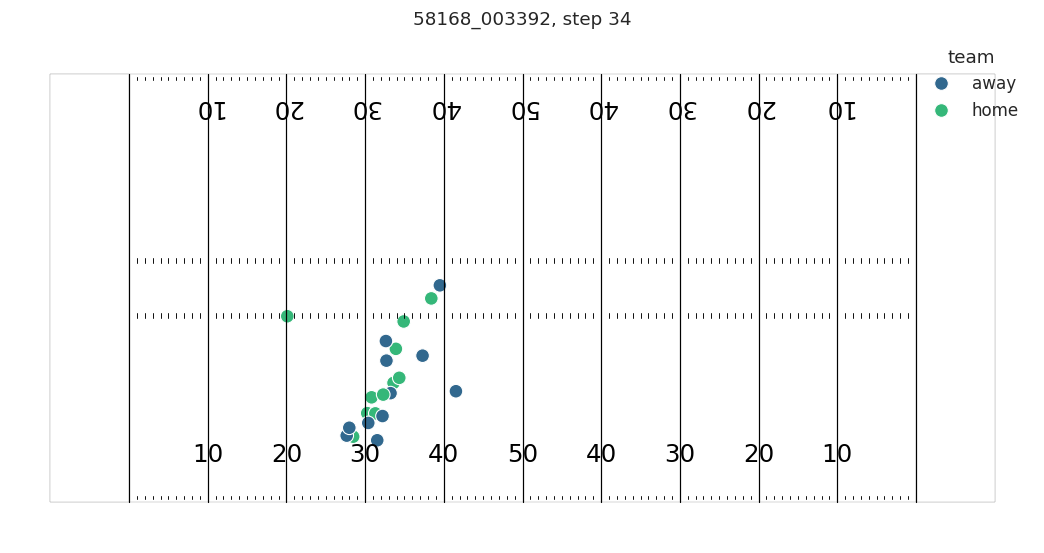

In [10]:
example_game_play = labels["game_play"].iloc[0]
example_step = int(labels.loc[labels["game_play"].eq(example_game_play), "step"].median())
example_tracking = train_tracking.query(
    "game_play == @example_game_play and step == @example_step"
).copy()

fig, ax = plt.subplots(figsize=(12, 6))
create_football_field(ax=ax)
if len(example_tracking):
    sns.scatterplot(
        data=example_tracking,
        x="x_position",
        y="y_position",
        hue="team",
        palette="viridis",
        s=80,
        ax=ax,
    )
    ax.set_title(f"{example_game_play}, step {example_step}")
plt.show()


## 11. Distance Baseline Sanity Check

Tune player-player distance thresholds with a play-grouped validation split. Ground rows are predicted as no-contact in this first baseline, making the limitation explicit.


Validation rows: 158,125
Validation plays: 8
Best threshold: 1.00 yards
Best MCC: 0.57635


,threshold,mcc,positive_rate
8,1.0,0.576348,0.012768
7,0.9,0.571641,0.010036
9,1.1,0.570792,0.016455
10,1.2,0.564836,0.019826
11,1.3,0.537885,0.023311
6,0.8,0.521334,0.007077
12,1.4,0.506416,0.026960
13,1.5,0.477270,0.030609
5,0.7,0.461177,0.004383
14,1.6,0.449206,0.034656


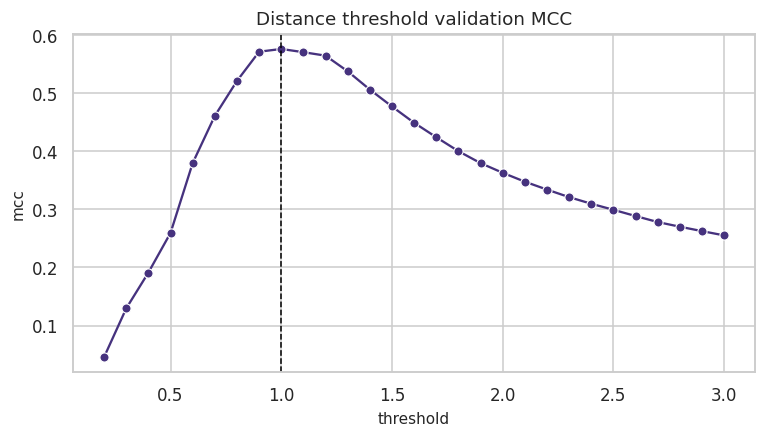

1248

In [11]:
work_labels = labels[[
    ID_COL, TARGET, "game_play", "step", "nfl_player_id_1",
    "nfl_player_id_2", "contact_type", "pair_key",
]].copy()
if RUN_FAST:
    work_labels = maybe_sample_plays(work_labels, FAST_SAMPLE_PLAYS)

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=RANDOM_STATE,
)
_, valid_idx = next(splitter.split(work_labels, groups=work_labels["game_play"]))
valid_labels = work_labels.iloc[valid_idx].copy()

valid_distances = compute_pair_distances(valid_labels, train_tracking)
valid_scoring = valid_labels.merge(
    valid_distances[[ID_COL, "distance"]],
    on=ID_COL,
    how="left",
)
threshold_scores = score_distance_thresholds(
    valid_scoring,
    DISTANCE_THRESHOLDS,
)
best_threshold = float(threshold_scores.iloc[0]["threshold"])
best_mcc = float(threshold_scores.iloc[0]["mcc"])

print(f"Validation rows: {len(valid_scoring):,}")
print(f"Validation plays: {valid_scoring['game_play'].nunique():,}")
print(f"Best threshold: {best_threshold:.2f} yards")
print(f"Best MCC: {best_mcc:.5f}")
display(threshold_scores.head(10))

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(
    data=threshold_scores.sort_values("threshold"),
    x="threshold",
    y="mcc",
    marker="o",
    ax=ax,
)
ax.axvline(best_threshold, color="black", linestyle="--", linewidth=1)
ax.set_title("Distance threshold validation MCC")
plt.show()

gc.collect()


### EDA Conclusions and Modeling Implications

The first EDA pass points to a two-branch solution. Player-player contact should start with distance, relative motion, and temporal smoothing. Player-ground contact needs a dedicated motion/video branch because player-player distance cannot detect it. Helmet boxes and synchronized Sideline/Endzone videos should be added after the tracking-only validation harness is stable.
